# Atractor de Lorenz

El sistema de Lorenz, propuesto en 1963 por Edward Lorenz, es un modelo clave para estudiar el caos determinista. En su publicación Deterministic Nonperiodic Flow, Lorenz lo describe como "el ejemplo más simple de flujo no periódico determinista". 
Desarrollado originalmente como una simplificación de las ecuaciones de Rayleigh-Bénar para estudiar la convección atmosférica y la búsqueda de patrones predecibles en fenómenos meteorológicos, este modelo se convirtió en uno de los primeros ejemplos documentados de comportamiento caótico. 
El sistema exhibe una sensibilidad extrema a las condiciones iniciales, fenómeno conocido como efecto mariposa, y genera un atractor extraño que impide predicciones a largo plazo, a pesar de su carácter determinista.
Debido a la naturaleza no lineal del sistema, las soluciones analíticas del sistema no pueden obtenerse fácilmente, por lo que su análisis requiere enfoques numéricos que permitan aproximar y visualizar su comportamiento complejo. 

# Método de Euler

Este método tiene por objetivo obtener una aproximación de un problema bien planteado de valor inicial

\begin{align*}
\frac{dy}{dt} = f(t, y), \quad a \leq t \leq b, \quad y(a) = \alpha \quad [5]
\end{align*} 

En la práctica, no se obtendrá una aproximación continua a la solución $y(t)$; por el contrario, se generarán aproximaciones a esa solución en varios valores, llamados puntos de red, en el intervalo $[a,b]$. Una vez obtenida la aproximación en los puntos, podemos obtener por interpolación la solución aproximada en otros puntos del intervalo.

En primer lugar, estipulamos que los puntos de red tienen una distribución uniforme en todo el intervalo $[a,b]$. Garantizamos esta condición al seleccionar un entero positivo $N$ y los puntos de red $t_i = a + ih, \quad \text{para cada } i = 0, 1, 2, \dots, N$ donde la distancia común entre los puntos $h = (b - a)dN$ recibe el nombre de tamaño de paso

Utilizaremos el teorema de Taylor para derivar el método de Euler [5]. Supongamos que $y(t)$ tiene dos derivadas continuas en $[a, b]$, de modo que para cada $i = 0, 1, 2, \dots, N - 1$

$$y(t_{i+1}) = y(t_i) + (t_{i+1} - t_i)y'(t_i) + \frac{(t_{i+1} - t_i)^2}{2} y''(\xi_i)$$

para algún número $\xi_i \in (t_i, t_{i+1}).$ Si $h = t_{i+1} - t_i$ entonces:

$$y(t_{i+1}) = y(t_i) + hy'(t_i) + \frac{h^2}{2} y''(\xi_i)$$,

$y$, como $y(t)$ satisface la ecuación diferencial:

$$y(t_{i+1}) = y(t_i) + h f(t_i, y(t_i)) + \frac{h^2}{2} y''(\xi_i)$$


El método de Euler construye \( w_i \approx y(t_i) \) para cada \( i = 1, 2, \dots, N \), al eliminar el término restante. Por tanto,

$w_0 = \alpha$

$$w_{i+1} = w_i + h f(t_i, w_i), \quad \text{para cada } i = 0, 1, \dots, N - 1$$

A esta ecuación se le llama ecuación de diferencias asociada al método de Euler. 

El método de Euler, como se presenta en Burden y Faires [5], se basa en una expansión de Taylor de primer orden de la solución exacta de una ecuación diferencial ordinaria. Al truncar esta serie después del primer término no trivial, se obtiene una fórmula explícita para aproximar la solución en puntos discretos: $w_{i+1} = w_i + h f(t_i, w_i)$

Aunque esta fórmula tiene una forma lineal respecto a $w_i$, el método **puede aplicarse a EDOs no lineales**, ya que la función $f(t, y)$ puede ser no lineal en $y$.

Sin embargo,  el método introduce un error local de orden $\mathcal{O}(h^2)$, lo que implica un **error global de orden $\mathcal{O}(h)$**. Esto lo hace menos preciso que métodos de mayor orden, como Runge-Kutta de orden 4, especialmente cuando se usa con pasos grandes.

Por tanto, el método de Euler se recomienda solo cuando se requieren cálculos rápidos y se puede tolerar una precisión limitada, o como paso inicial para métodos más complejos.

## Implementación en código del Método de Euler

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Definición del sistema de Lorenz
def lorenz_system(x, y, z, sigma, rho, beta):
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return dx, dy, dz

In [3]:
# Método de Euler
def euler_method(x0, y0, z0, sigma, rho, beta, dt, t_max):
    xs, ys, zs = [x0], [y0], [z0]
    x, y, z = x0, y0, z0
    steps = int(t_max / dt)
    for _ in range(steps):
        dx, dy, dz = lorenz_system(x, y, z, sigma, rho, beta)
        x += dx * dt
        y += dy * dt
        z += dz * dt
        xs.append(x)
        ys.append(y)
        zs.append(z)
    return xs, ys, zs

In [7]:
# Parámetros y condiciones iniciales
dt = 0.01
t_max = 70

In [8]:
# Función para graficar resultados
def plot_lorenz(xs, ys, zs, title):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.plot(xs, ys, zs)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.tight_layout()
    plt.show()

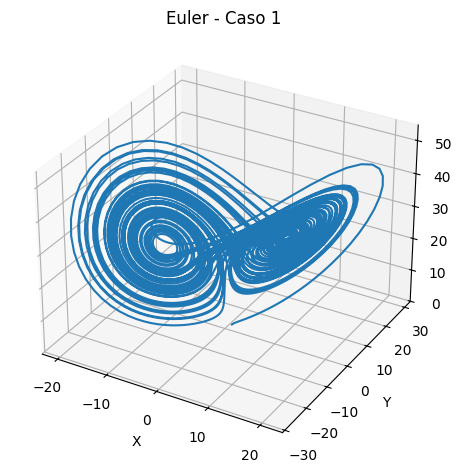

In [9]:
# Caso 1
# Condiciones iniciales (x(0),y(0),z(0))
x0, y0, z0 = 1, 1, 1

# Condiciones para el atractor de Lorenz:
sigma = 10
rho = 28
beta = 8/3

xs, ys, zs = euler_method(x0, y0, z0, sigma, rho, beta, dt, t_max)
plot_lorenz(xs, ys, zs, "Euler - Caso 1")

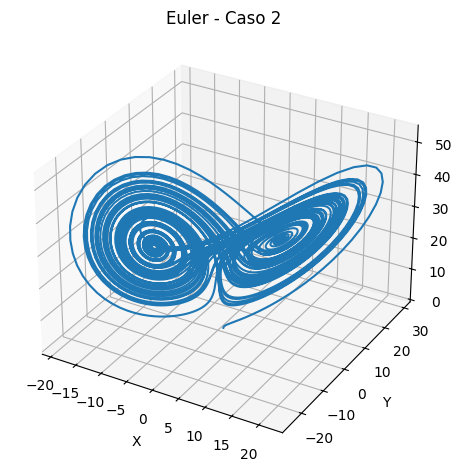

In [13]:
# Caso 2
# Condiciones iniciales (x(0),y(0),z(0))
x0, y0, z0 = 1.002025, 0.2, 0.4
# Condiciones para el atractor de Lorenz:
sigma = 10
rho = 28
beta = 8/3

xs, ys, zs = euler_method(x0, y0, z0, sigma, rho, beta, dt, t_max)
plot_lorenz(xs, ys, zs, "Euler - Caso 2")

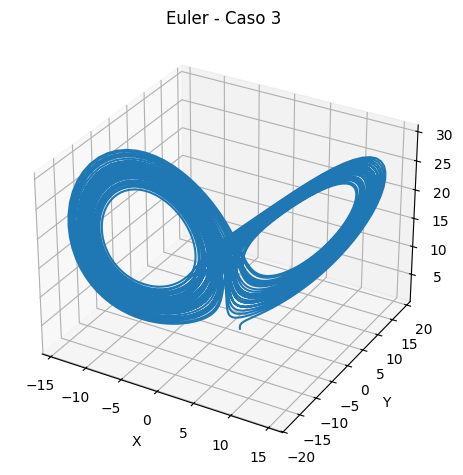

In [15]:
# Caso 3
# Condiciones iniciales (x(0),y(0),z(0))
x0, y0, z0 = 2, 0.009, 0.7

# Condiciones para el atractor de Lorenz:
sigma = 9
rho = 18
beta = 10/3

xs, ys, zs = euler_method(x0, y0, z0, sigma, rho, beta, dt, t_max)
plot_lorenz(xs, ys, zs, "Euler - Caso 3")

#### Gráficas de x, y y z en función del tiempo para cada uno de los casos.

In [25]:
def plot_lorenz_case(x0, y0, z0, sigma, rho, beta, dt, t_max, title):
    # Simulación con método de Euler
    xs, ys, zs = euler_method(x0, y0, z0, sigma, rho, beta, dt, t_max)
    steps = int(t_max / dt)
    time = np.linspace(0, t_max, steps + 1)

    # Convertir los resultados a una matriz tipo Y para facilitar graficación por índices
    Y = np.zeros((3, steps + 1))
    Y[0, :] = xs
    Y[1, :] = ys
    Y[2, :] = zs

    # Gráficas
    fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    fig.suptitle(title, y=0.925, fontsize=16)

    axs[0].plot(time, Y[0, :], label='x(t)')
    axs[0].legend()

    axs[1].plot(time, Y[1, :], label='y(t)', color='teal')
    axs[1].legend()

    axs[2].plot(time, Y[2, :], label='z(t)', color='steelblue')
    axs[2].legend()
    axs[2].set_xlabel("Tiempo")

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

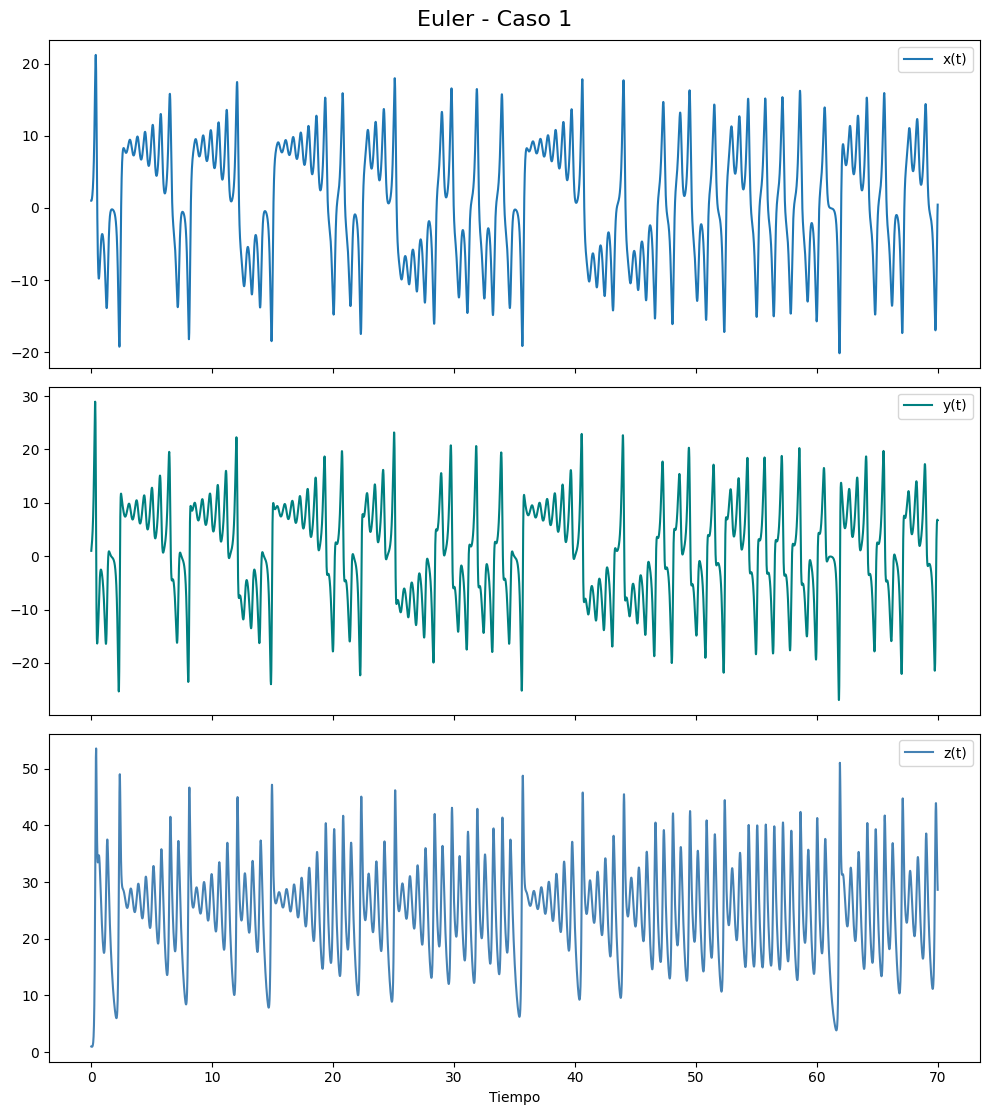

In [27]:
# Caso 1
# Condiciones iniciales (x(0),y(0),z(0))
x0, y0, z0 = 1, 1, 1

# Condiciones para el atractor de Lorenz:
sigma = 10
rho = 28
beta = 8/3

xs, ys, zs = euler_method(x0, y0, z0, sigma, rho, beta, dt, t_max)
plot_lorenz_case(x0, y0, z0, sigma, rho, beta, dt, t_max, "Euler - Caso 1")

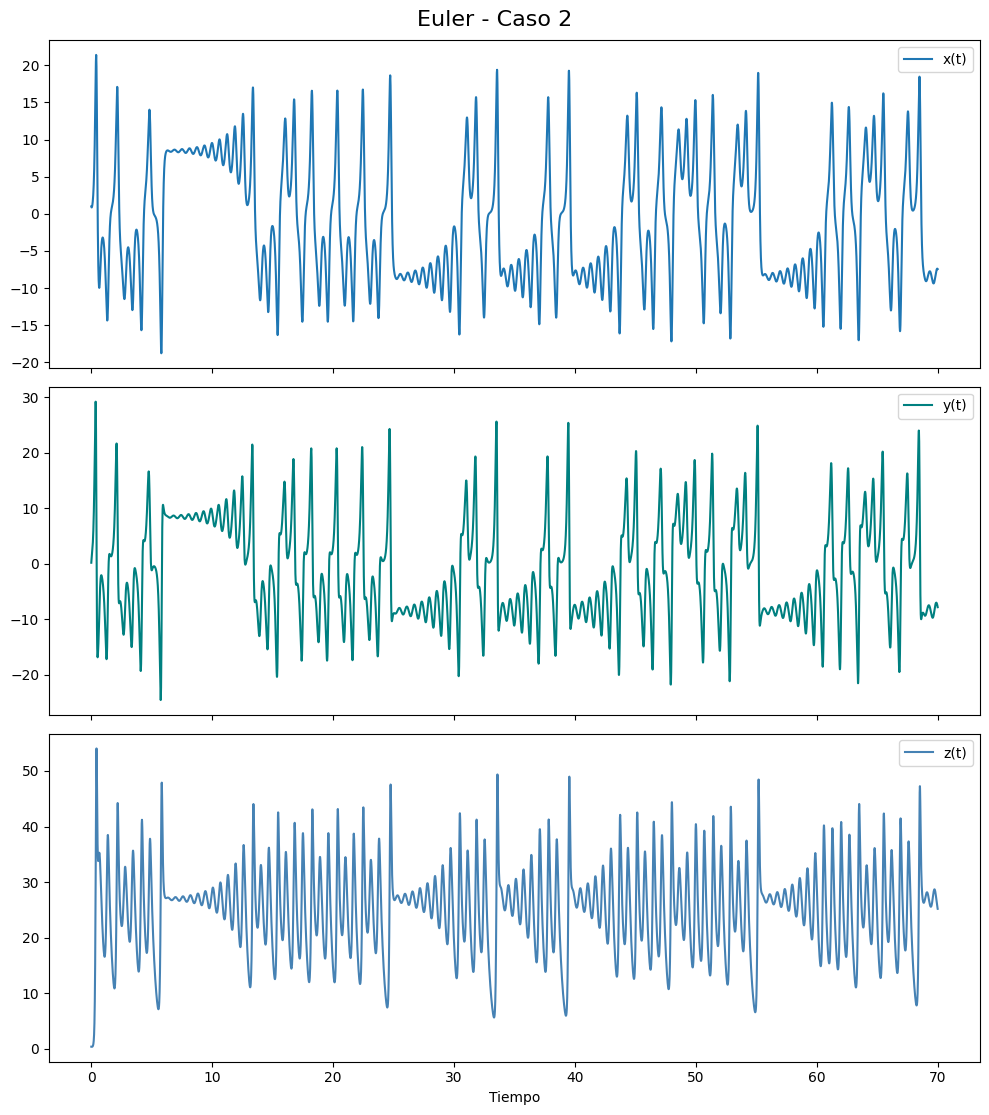

In [29]:
# Caso 2
# Condiciones iniciales (x(0),y(0),z(0))
x0, y0, z0 = 1.002025, 0.2, 0.4
# Condiciones para el atractor de Lorenz:
sigma = 10
rho = 28
beta = 8/3

xs, ys, zs = euler_method(x0, y0, z0, sigma, rho, beta, dt, t_max)
plot_lorenz_case(x0, y0, z0, sigma, rho, beta, dt, t_max, "Euler - Caso 2")

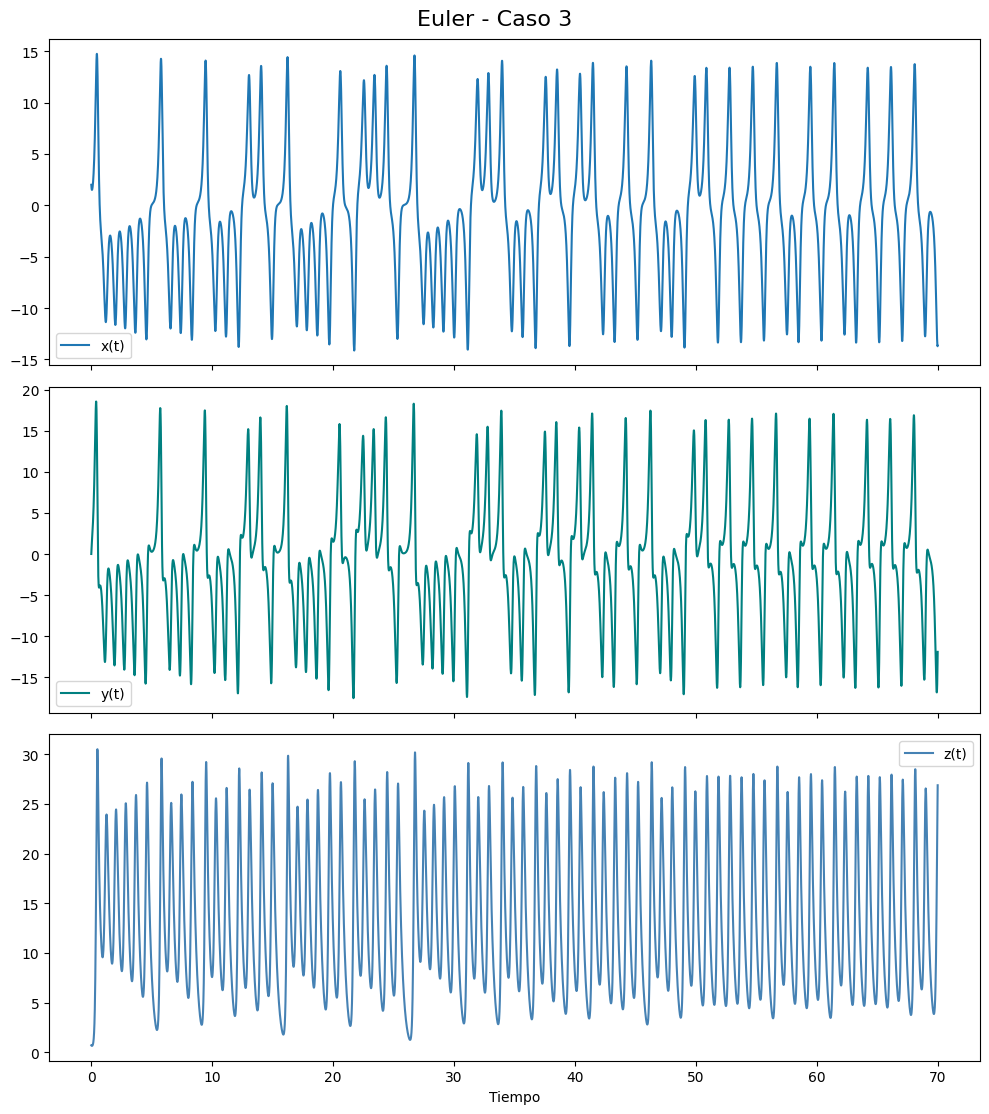

In [31]:
# Caso 3
# Condiciones iniciales (x(0),y(0),z(0))
x0, y0, z0 = 2, 0.009, 0.7

# Condiciones para el atractor de Lorenz:
sigma = 9
rho = 18
beta = 10/3

xs, ys, zs = euler_method(x0, y0, z0, sigma, rho, beta, dt, t_max)
plot_lorenz_case(x0, y0, z0, sigma, rho, beta, dt, t_max, "Euler - Caso 3")

## Análisis de variación en la dinámica del sistema ante los cambios en las condiciones iniciales


El sistema de Lorenz es conocido por presentar una dinámica caótica sensible a las condiciones iniciales [1]. 

En este análisis, se han simulado tres conjuntos de condiciones iniciales usando el método de Euler usando los parámetros clásicos de Lorenz en los primeros dos casos y usando $\sigma = 10, \quad \rho = 28, \quad \beta = \frac{8}{3}$ y para el tercer caso $\sigma = 9, \quad \rho = 18, \quad \beta = \frac{10}{3}$.

Con las condiciones iniciales para $(x_0, y_0, z_0)$:

- **Caso 1**:  $(x_0, y_0, z_0)$ = (1,1,1)
- **Caso 2**:  $(x_0, y_0, z_0)$ = (1.002025,0.2,0.4)
- **Caso 1**:  $(x_0, y_0, z_0)$ = (2,0.009,0.7)

- **Caso 1 y Caso 2**, A pesar de que los parámetros $\beta, \sigma $ y $\rho$ se mantuvieron iguales para el sistema de Lorenz para los primeros dos casos, con ligeras variaciones en sus condiciones iniciales, se pueden observar notables diferencias en las gráficas. Esto deja en evidencia que pequeñas variaciones en las condiciones iniciales pueden generar trayectorias completamente diferentes con el tiempo, aunque comiencen con comportamientos muy similares [4], lo que ilustra el efecto mariposa y la dependencia significativa en las condiciones iniciales. Además, se resalta que debido a la alta propagación de errores y baja precisión de Euler, especialmente para sistemas caóticos como el caso 3, se muestran varias oscilaciones. CITAAAAAAAR
- **Caso 3**, en este caso se han modificado las condiciones para el atractor de Lorenz, por lo tanto en su gráfica se observa un comportamiendo sumamente distinto, las oscilaciones tienen distinta amplitud, frecuencia y simetría, lo que resalta el hecho de que tanto las condiciones iniciales como las condiciones para el atractor de Lorenz determinan la naturaleza del atractor [2]. Se observa un comportamiento menos errático.

## Explicación de cómo afecta la variación de los parámetros en el comportamiento del sistema

La variable $\rho$ está relacionado con el número de Rayleigh y mide la tendencia de un fluido a generar convección. A medida que $\rho$ el sistema atraviesa estados estables, oscilaciones periódicas y comportamientos caóticos.
De acuerdo a Lorenz, los umbrales críticos para cambios en el comportamiento cualitativo del sistema $(\sigma = 10, \beta = 8/3)$ son:
- $\rho < 1$: el único punto de equilibrio estable es el origen.
- 1 < $\rho$ < $\rho \approx 24.74$: surgen dos puntos de equilibrio no triviales estables
- $\rho > \rho_H$: los puntos de equilibrio pierden estabilidad y aparece un atractor extraño. [1]

$\sigma$ Representa el número de Prandtl, que mide la difusión térmica, es decir, la velocidad con la que el sistema reacciona a desequilibrios térmicos. Matemáticamente $(\sigma/(y-x))$, controla la rapidez de respuesta de x (convección en el fluido) frente a y (temperatura horizonal entre dos corrientes)
$\sigma = 10$ en los dos primeros casos es el valor clásico, con oscilaciones caóticas definidas, equilibra la velocidad de acoplamiento entre variables [2]. 
En cuanto mayor sea el valor de $\sigma$, mayor complejidad y frecuencia poseen las oscilaciones caóticas y existe, al existir mayor sensibilidad en el eje x.  

$\beta$ Representa la tasa de disipación vertical. En cuanto menor sea el valor, menor disipación hay en el sistema. En otras palabras, el sistema pierde menos energía y las trayectorias son más amplias y persistentes en el tiempo. [2] Para el vlaor clásico $8/3$, existe una disipación equilibrarda, con trayectorias caóticas bien contenidas. 

- **Caso 1:** Parámetros clásicos de Lorenz, exhibe comportamiento caótico. Ya que $\rho = 28$ supera el umbral crítico $(\rho \approx 24.74)$, lo que desestabiliza los puntos fijos no triviales y da lugar al atractor extraño, por lo que se espera un comportamiento caótico caracterizado por oscilaciones irregulares en las variables. La condición inicial simétrica (1,1,1) lleva a trayectorias que oscilan irregularmente entre los dos lóbulos del atractor. $\sigma = 10$ asegura un acoplamiento rápido entre x e y, mientras que $\beta = 8/3$ mantiene la disipación equilibrada, evitando que las oscilaciones crezcan sin control.
- **Caso 2:** Al mantener los mismos parámetros con pequeñas diferencias en los valores iniciales, el sistema sigue siendo caótico, pero con trayectorias distintas a largo plazo debido a la sensibilidad extrema a las condiciones iniciales.
- **Caso 3:** Se encuentra por debajo del umbral de transición caótica  $\rho = 18 < 24.74$, por lo que, el sistema ya no es caótico y se observa un comportamiento menos errático con oscilaciones suaves, en el que se puede tender hacia un punto fijo estable, influido también por una mayor disipación vertial $\beta = 10/3$

## Comparación de métodos
Después de implementar y comparar ambos métodos, se concluye que el método de Runge-Kutta de cuarto orden (RK4) resulta significativamente más eficaz que el método de Euler para simular el sistema de Lorenz. Esto se debe a que RK4 ofrece mayor precisión y estabilidad numérica que el método de Euler, especialmente en un sistema tan sensible a las condiciones iniciales. A diferencia de Euler, que es un método de primer orden con error global $\mathcal{O}(h)$, RK4 es un método de cuarto orden con error global $\mathcal{O}(h^4)$, lo que le permite obtener soluciones mucho más cercanas a la trayectoria real del sistema incluso con pasos de tiempo moderadamente grandes. Aunque RK4 requiere más evaluaciones de la función por paso, esta mayor carga computacional se compensa con una mejor aproximación y menor acumulación de error.
Por el contrario, el método de Euler, al ser más simple y menos preciso, acumula errores rápidamente, especialmente en modelos caóticos como el de Lorenz. Esto puede dar lugar a trayectorias que divergen del comportamiento físico esperado, a menos que se utilice un tamaño de paso extremadamente pequeño, lo cual lo hace ineficiente.

Este comportamiento concuerda con lo discutido en la literatura, donde se explica que métodos de orden superior como RK4 logran mejores aproximaciones con menor error global y mayor estabilidad en problemas donde no se conoce una solución exacta. [5]

# Análisis del Sistema

## 1. Puntos fijos o de equilibrio

Las ecuaciones de Lorenz son:

\begin{align*}
\frac{dx}{dt} &= \sigma (y - x), \\
\frac{dy}{dt} &= r x - y - x z, \quad \\
\frac{dz}{dt} &= x y - b z.
\end{align*}

Donde $\sigma , r, b > 0$ son parámetros. $\sigma$ es el número Prandtl, $r$ es el número Rayleigh y $b$ no tiene nombre. 

En las ecuaciones de Lorenz existe una simetría importante. Si reemplazamos $(x,y) (-x,-y)$ en $(1)$, las ecuaciones se mantienen. Por tanto, si  $(x(t), y(t), z(t)$ es una solución, también lo es  $(-x(t), -y(t), -z(t)$. Todas las soluciones son simétricas en sí mismas o tienen una pareja simétrica. [2]

### Definición de punto fijo

Los puntos fijos representan soluciones de equilibrio, también llamadas como soluciones estacionarias, constantes o de reposo, ya que si $x = x^*$ inicialmente, entonces $x(t) = x^*$ permanentemente. Supongamos que $x^*$ satisface $f(x^*) = x^*$. Entonces, $x^*$ es un punto fijo. [2]

Existen dos puntos de tipos fijos: 
- Estables: a menudo llamados atractores o sumidores porque el flujo se dirige hacia ellos. Los equilibros estables suceden cuando todas las perturbaciones suficientemente pequeñas que se alejan de él se amortiguan con el tiempo y se reprsentan geométricamente mediante puntos fijos estables.
- Inestables: también conocidos como repelentes o fuentes porque el flujo se aleja de él, por lo que las perturbaciones aumentan con el tiempo. [2]

### Linealización para sistemas unidimensionales

Sea $x^*$ un punto fijo, y sea $\eta(t) = x(t) - x^*$ una pequeña perturbación lejos de $x^*$. Para ver si la perturbación crece o decrece, derivamos una eduación diferencial para $\eta$:

$$
\frac{d\eta}{dt} = \frac{d}{dt}(x - x^*) = \frac{dx}{dt}
$$

Dado que $x^*$ es constante. Así $\frac{d\eta}{dt} = \frac{dx}{dt} = f(x) = f(x^* + \eta).$ Usando Taylor alrededor de $x^*$:

$$
f(x^* + \eta) = f(x^*) + \eta f'(x^*) + O(\eta^2),
$$

donde $O(\eta^2)$ denota términos cuadráticamente pequeños en $\eta$ y que $f(x^*) = 0$ (por ser punto fijo). Si $f'(x^*) \neq 0$, la aproximación lineal es:

$$
\frac{d\eta}{dt} = \eta f'(x^*) + O(\eta^2). 
$$

Pero si $f(x^*) \neq 0$, los $O(\eta^2)$ términos son despreciables y podemos escribir la aproximación como:
$$
\frac{d\eta}{dt} = \eta f'(x^*)
$$

Esta es una ecuación lineal en $\eta$ denominada lineralización respecto a $x^*$. [2, p. 24]


Como muestra Strogatz [2], la pendiente de $f'(x^*)$ en el punto fijo determina su estabilidad:
- Si $f'(x^*) > 0$, la perturbación crece exponencialmente y se trata de un punto fijo inestable.
- Si $f'(x^*) < 0$, la perturbación decae y se trata de un punto fijo estable.
- Si $f'(x^*) = 0$, los términos $O(\eta^2)$ no son despreciables y no se puede concluir nada con este análisis lineal, hay que usar otro método no lineal para dterminar la estabilidad [2]

Su recíproco $\frac{1}{|f'(x^*)|}$ es una escala de tiempo característica; determina el tiempo requerido para que $x(t)$ varíe significativamente en la vecindad de $(x^*)$

### Linealización para sistemas multivariables

Dado que el sistema de Lorenz es de 3 dimensiones, interesa extender la técnica de linealización a sistemas multidimensionales. Este método sigue el enfoque descrito en [2, Sección 6.3] para puntos fijos y linealización

Se considera el sistema

\
\begin{aligned}
\dot{x} &= f(x, y, z) \\
\dot{y} &= g(x, y, z) \\
\dot{z} &= h(x, y, z)
\end{aligned}

y se supone que $(x^*, y^*)$ es un punto fijo, i.e.,

$$f(x^*, y^*, z^*) = 0, \quad g(x^*, y^*, z^*) = 0, \quad h(x^*, y^*, z^*) = 0.$$

Definimos perturbaciones pequeñas: 
$$ u = x - x^*, \quad v = y - y^*, \quad w = z - z^*$$

Aplicamos expansión de Taylor multivariable para cada ecuación
\begin{aligned}
\text{(dado que $x^*$ es constante)} \quad 
\dot{u} &= \dot{x}  \\
 \quad \text{(por sustitución)}
&= f(x^* + u, y^* + v, z^* + w) \\
\quad \text{(expansión de Taylor)} 
&= f(x^*, y^*, z^*) + u \frac{\partial f}{\partial x}\bigg|_{(x^*,y^*,z^*)} + v \frac{\partial f}{\partial y}\bigg|_{(x^*,y^*,z^*)} + w \frac{\partial f}{\partial z}\bigg|_{(x^*,y^*,z^*)} \\
&\quad + O(u^2, v^2, w^2, uv, uw, vw)\\
\quad \text{(pues $f(x^*,y^*,z^*) = 0$)}
&= u \frac{\partial f}{\partial x}\bigg|_{(x^*,y^*,z^*)} + v \frac{\partial f}{\partial y}\bigg|_{(x^*,y^*,z^*)} + w \frac{\partial f}{\partial z}\bigg|_{(x^*,y^*,z^*)} 
\end{aligned}

Repetimos el proceso para las dos ecuaciones faltantes:

\begin{aligned}
\dot{w} &= \dot{z} \\
&= h(x^* + u, y^* + v, z^* + w) \\
&= h(x^*, y^*, z^*) + u \frac{\partial h}{\partial x}\bigg|_{(x^*,y^*,z^*)} + v \frac{\partial h}{\partial y}\bigg|_{(x^*,y^*,z^*)} + w \frac{\partial h}{\partial z}\bigg|_{(x^*,y^*,z^*)} \\
&\quad + O(u^2, v^2, w^2, uv, uw, vw) \\
&= u \frac{\partial h}{\partial x}\bigg|_{(x^*,y^*,z^*)} + v \frac{\partial h}{\partial y}\bigg|_{(x^*,y^*,z^*)} + w \frac{\partial h}{\partial z}\bigg|_{(x^*,y^*,z^*)}
\end{aligned}

\begin{aligned}
\dot{v} &= \dot{y} \\
&= g(x^* + u, y^* + v, z^* + w) \\
&= g(x^*, y^*, z^*) + u \frac{\partial g}{\partial x}\bigg|_{(x^*,y^*,z^*)} + v \frac{\partial g}{\partial y}\bigg|_{(x^*,y^*,z^*)} + w \frac{\partial g}{\partial z}\bigg|_{(x^*,y^*,z^*)} \\
&\quad + O(u^2, v^2, w^2, uv, uw, vw) \\
&= u \frac{\partial g}{\partial x}\bigg|_{(x^*,y^*,z^*)} + v \frac{\partial g}{\partial y}\bigg|_{(x^*,y^*,z^*)} + w \frac{\partial g}{\partial z}\bigg|_{(x^*,y^*,z^*)}
\end{aligned}

Por tanto, la perturbación $(u,v,w)$ evoluciona de acuerdo a:
$$
\begin{pmatrix}
\dot{u} \\
\dot{v}
\end{pmatrix}
=
\begin{pmatrix}
\frac{\partial f}{\partial x} & \frac{\partial f}{\partial y} & \frac{\partial f}{\partial z} \\
\frac{\partial g}{\partial x} & \frac{\partial g}{\partial y} & \frac{\partial g}{\partial z} \\
\frac{\partial g}{\partial x} & \frac{\partial h}{\partial y} & \frac{\partial h}{\partial z}
\end{pmatrix}
\begin{pmatrix}
u \\
v \\
w
\end{pmatrix}
+ \text{términos cuadráticos.}
$$

La matriz

$$
A =
\begin{pmatrix}
\frac{\partial f}{\partial x} & \frac{\partial f}{\partial y} & \frac{\partial f}{\partial z} \\
\frac{\partial g}{\partial x} & \frac{\partial g}{\partial y} & \frac{\partial g}{\partial z} \\
\frac{\partial g}{\partial x} & \frac{\partial h}{\partial y} & \frac{\partial h}{\partial z}
\end{pmatrix}_{(x^*,y^*,z^*)}
$$

es llamada matriz jacobiana en el punto fijo $(x^*,y^*,^*)$. Es el análogo multivariable de la derivada $f'(x^*)$ para sistemas de una sola dimensión.

Dado que los términos cuadráticos son minúsculos, pueden ser ignorados por completo, obteniendo el sistema linealizado sin que la solución se vea afectada.
$$
\begin{pmatrix}
\dot{u} \\
\dot{v} \\
\dot{w}
\end{pmatrix}
=
\begin{pmatrix}
\frac{\partial f}{\partial x} & \frac{\partial f}{\partial y} & \frac{\partial f}{\partial z} \\
\frac{\partial g}{\partial x} & \frac{\partial g}{\partial y} & \frac{\partial g}{\partial z} \\
\frac{\partial g}{\partial x} & \frac{\partial h}{\partial y} & \frac{\partial h}{\partial z}
\end{pmatrix}
\begin{pmatrix}
u \\ 
v \\
w
\end{pmatrix}
$$



### Puntos fijos en el sistema de Lorenz

#### 1. Se encuentran los puntos fijos resolviendo \begin{align*}
\frac{dx}{dt} &= \sigma (y - x) = 0, \\
\frac{dy}{dt} &= r x - y - x z = 0, \quad \\
\frac{dz}{dt} &= x y - \beta z = 0.\quad  [2]
\end{align*} 

De la primera ecuación:  
   $$\sigma(y - x) = 0 \implies y = x \quad (pues \ \sigma \neq 0)$$.
Sustituyendo $y = x$ en la tercera ecuación:  
   $$x^2 = \beta z \implies z = \frac{x^2}{\beta}$$.
Sustituyendo $y = x$ y $z = \frac{x^2}{\beta}$ en la segunda ecuación:  
   $$x(\rho - 1 - \frac{x^2}{\beta}) = 0$$.

La matriz jacobiana del sistema es:
\begin{bmatrix}
-\sigma & \sigma & 0 \\
\rho - z & -1 & -x \\
y & x & -\beta
\end{bmatrix}

#### 2. Solución 1:
   - Caso trivial: $x^*, y^*, z^* = 0$
Linealizando alrededor de $(0,0,0)$ la matriz jacobiana es:
$$
J = \begin{bmatrix}
-\sigma & \sigma & 0 \\
\rho & -1 & 0 \\
0 & 0 & -\beta
\end{bmatrix}
$$

$$
J = \begin{bmatrix}
-10 & 10 & 0 \\
28 & -1 & 0 \\
0 & 0 & -\frac{8}{3}
\end{bmatrix}
$$

Con ecuación característica:
$$\lambda^3 + (\sigma + \beta + 1)\,\lambda^2 + (\rho\sigma + \beta\sigma)\,\lambda + 2\beta\sigma(\rho - 1) = 0.$$

Y soluciones:
$$
\lambda_1 = -\beta, \quad \lambda_{2,3} = \frac{-(\sigma+1) \pm \sqrt{(\sigma-1)^2 + 4\sigma(\rho-1)}}{2}
$$
- Para $\rho < 1$: Todos $\text{Re}(\lambda_i) < 0$, es decir, todos los autovalores tienen parte real negativa, entonces el origen es estable.  
- Para $\rho > 1$: Un autovalor positivo, cambia el término independiente a negativo y el origen se vuelve inestable. [2]

#### 3. Soluciones no triviales $$x^* = y^* = \pm\sqrt{\beta(\rho-1)}, \quad z^* = \rho-1$$ 
- Existen solo si $\rho > 1$ porque $x^2 = \beta(\rho -1) \implies \rho > 1 \ para \ que \ x  \in \mathbb{R}$.
  Son puntos simétricos a los que Lorenz llamó $C^+$ y $C^-$, representan rollos de convección que giran a la izquierda o a la derecha. [1]
- Matriz jacobiana:

$$
J = \begin{bmatrix}
-\sigma & \sigma & 0 \\
1 & -1 & -x^* \\
x^* & x^* & -\beta
\end{bmatrix}
$$


#### 4. Caso específico
Con los parámetros clásicos:
$\sigma = 10, \quad \rho = 28, \quad \beta = \frac{8}{3} \quad $ 
Sustituimos en la ecuación característica general 
$$\lambda^3 + (\sigma + \beta + 1)\,\lambda^2 + (\rho\sigma + \beta\sigma)\,\lambda + 2\beta\sigma(\rho - 1) = 0.$$

  $$\lambda^3 + (10 + \frac{8}{3} + 1)\lambda^2 + (10 \cdot 28 + \frac{8}{3} \cdot 10)\lambda + 2 \cdot \frac{8}{3} \cdot 10 \cdot (28 -1) = 0$$.
  $$\lambda^3 + \frac{41}{3}\lambda^2 + (\frac{304}{3})\lambda + 1440 = 0$$
   - Autovalores: $\lambda_1 \approx -13.85$, $\lambda_{2,3} \approx 0.094 \pm 10.19i$.
   - Entonces, los puntos fijos son:
(0, 0, 0)\) (8.485, 8.485, 27) (-8.485, -8.485, 27)
   - Conclusión: Inestables (focos repulsores), ya que los autovalores incluyen una parte real positiva $\lambda_{2,3} \approx 0.094$ que indica inestabilidad. La parte imaginaria, por otra parte, revela comportamiento oscilatorio.

#### 4. Comprobando mediante código

In [125]:
import numpy as np
from numpy.linalg import eig # para calcular autovalores

# Parámetros clásicos
sigma = 10
rho = 28
beta = 8 / 3

# Punto trivial que existe siempre
P0 = np.array([0.0, 0.0, 0.0])
puntos_fijos = [P0]

# Puntos no triviales (solo si rho > 1)
if rho > 1:
    x_val = np.sqrt(beta * (rho - 1))
    z_val = rho - 1
    P_plus  = np.array([ x_val,  x_val, z_val])
    P_minus = np.array([-x_val, -x_val, z_val])
    puntos_fijos.extend([P_plus, P_minus])

# Función para calcular Jacobiano del sistema de Lorenz
def jacobiano(x, y, z, sigma, rho, beta):
    return np.array([
        [-sigma,     sigma,      0     ],
        [rho - z,    -1,        -x     ],
        [y,          x,         -beta  ]
    ])

print(f"Puntos fijos del sistema de Lorenz (σ = {sigma}, ρ = {rho}, β = {beta:.4f}):\n")

for i, P in enumerate(puntos_fijos):
    x, y, z = P
    print(f"Punto fijo {i}: ({x:.4f}, {y:.4f}, {z:.4f})")

    # Jacobiano y autovalores
    J = jacobiano(x, y, z, sigma, rho, beta)
    autovalores = eig(J)[0]

    # Clasificar estabilidad
    estable = np.all(np.real(autovalores) < 0)
    tipo = "estable" if estable else "inestable"

    print("  Autovalores:")
    for l in autovalores:
        print(f"   λ = {l:.4f}")
    print(f"  → El punto es {tipo}.\n")

Puntos fijos del sistema de Lorenz (σ = 10, ρ = 28, β = 2.6667):

Punto fijo 0: (0.0000, 0.0000, 0.0000)
  Autovalores:
   λ = -22.8277
   λ = 11.8277
   λ = -2.6667
  → El punto es inestable.

Punto fijo 1: (8.4853, 8.4853, 27.0000)
  Autovalores:
   λ = -13.8546+0.0000j
   λ = 0.0940+10.1945j
   λ = 0.0940-10.1945j
  → El punto es inestable.

Punto fijo 2: (-8.4853, -8.4853, 27.0000)
  Autovalores:
   λ = -13.8546+0.0000j
   λ = 0.0940+10.1945j
   λ = 0.0940-10.1945j
  → El punto es inestable.



##### Nota: 
Si los valores de sigma = 10, rho = 28 y beta = 8 / 3, son cambiados en el código a sigma = 9, rho = 18 y beta = 10 / 3 se obtienen puntos estables, dado que 
$$
\sigma(\sigma+\beta+3) = 9 \times \left(9 + \frac{10}{3} + 3\right) = 9 \times \frac{46}{3} = 138
$$

$$
\sigma - \beta - 1 = 9 - \frac{10}{3} - 1 = \frac{27}{3} - \frac{10}{3} - \frac{3}{3} = \frac{14}{3}
$$

$$
\rho_c = \sigma(\sigma+\beta+3)/(\sigma-\beta-1) = \frac{138}{\frac{14}{3}} = \frac{138 \times 3}{14} = \frac{414}{14} \approx 29.571
$$

Dado que $\rho > \rho_c$ no se cumple ($18 \ngtr 29.571$) el punto no trivial no se vuelve inestable. 

#### 5. Análisis
El sistema de Lorenz presenta un comportamiento fuertemente dependiente del parámetro $\rho$. Cuando $\rho < 1$, el único punto fijo existente es el origen, el cual es estable: todas las trayectorias convergen hacia él. Sin embargo, cuando $\rho$ supera el umbral crítico de 1, el origen se vuelve inestable, y emergen dos nuevos puntos fijos simétriocos $P_+$ y $P_-$, producto de una bifurcación. 
Estos puntos no triviales existen solo para $\rho > 1$, y se localizan simétricamente en torno al origen. Inicialmente, son estables, pero para valores mayores de $\rho$ en particular cuando $\rho > \rho_c \approx 24.72$ (donde $\rho_c = \sigma(\sigma+\beta+3)/(\sigma-\beta-1)$ también se vuelven inestables [1]. El sistema entra en una fase caótica, caracterizada por trayectorias no periódicas que no convergen a ningún punto fijo. Este último punto, Lorenz lo establece así: "Todas las soluciones, y en particular las periódiccas, resultan inestables. Por lo tanto, las demás soluciones no pueden, en general, aproximarse asintóticamente a las periódicas, por lo que son no periódicas". [1] El análisis espectral de la matriz Jacobiana en cada punto fijo permite clasificar su estabilidad mediante los autovalores: si todos tienen parte real negativa, el punto es estable; si alguno tiene parte real positiva, el punto es inestable. En el caso clásico con $\sigma = 10, \quad \rho = 28, \quad \beta = \frac{8}{3}$, se observa que los tres puntos fijos existen, pero todos son inestables, siendo los puntos no triviales focos repulsores con autovalores complejos conjugados de parte real positiva.

## 2. Cálculo de ($\nabla \cdot F$) del sistema de Lorenz


El sistema de Lorenz define un campo vectorial $\vec{F}(x, y, z)$ cuyas componentes son:

\begin{aligned}
F_1(x, y, z) &= \sigma(y - x) \\
F_2(x, y, z) &= x(\rho - z) - y \\
F_3(x, y, z) &= xy - \beta z
\end{aligned}

Y cuya divergencia se calcula como:

$$\nabla \cdot \vec{F} = \frac{\partial F_1}{\partial x} + \frac{\partial F_2}{\partial y} + \frac{\partial F_3}{\partial z}$$

Derivando cada componente:

\begin{aligned}
\frac{\partial F_1}{\partial x} &= -\sigma \\
\frac{\partial F_2}{\partial y} &= -1 \\
\frac{\partial F_3}{\partial z} &= -\beta
\end{aligned}

$$
\nabla \cdot F = -\sigma - 1 - b $$

Por lo tanto:

$\nabla \cdot \vec{F} = -(\sigma + 1 + \beta) \quad [1] $ 

Con los valores clásicos del sistema $\sigma = 10, \beta = \frac{8}{3}$, esto da:
$$
\nabla \cdot \vec{F} = -\left(10 + 1 + \frac{8}{3} \right) = -\frac{41}{3} \approx -13.67
$$

### Interpretación geométrica

La divergencia de un campo vectorial mide la variación local del volumen en el espacio de fases.  
En este caso, como $\nabla \cdot \vec{F} < 0$ para todos los valores positivos de los parámetros, el sistema de Lorenz es **volumétricamente contractivo**: cualquier región pequeña en el espacio de fases disminuirá su volumen con el tiempo. Tal como lo señaló Lorenz "Cada pequeño volumen se contrae hasta cero a medida que $r \implies \infty$ a una velocidad independiente de $X, Y$ y $Z$. Esto no implica que cada pequeño volumen se contraiga hasta un punto; simplemente puede aplanarse hasta convertirse en una superficie" [1]

Geométricamente, esto significa que las trayectorias del sistema tienden a colapsar hacia un subconjunto de menor dimensión al contrarse —por ejemplo, hacia un atractor.  
Esto es coherente con el comportamiento observado del sistema de Lorenz, en el cual las soluciones tienden hacia un atractor extraño: una estructura caótica pero contenida en el las trayectorias se confinan a una región acotada a pesar de su comportamiento caótico.

Además, la traza del Jacobiana coincide con la divergencia:
La variación del  $Vo$ de una pequeña región en el espacio de fases, a medida que cada punto de la región se desplaza, está determinada por la suma diagonal de la matriz de coeficientes, específicamente: $Vo = -(\sigma + b + 1)Vo$ [1]
\begin{bmatrix}
-\sigma & \sigma & 0 \\
\rho - z & -1 & -x \\
y & x & -\beta
\end{bmatrix}


## 3. Expresión para la integral de flujo $\frac{dV(t)}{dt} = \oint_{S(t)} \mathbf{F} \cdot d\mathbf{S}$

Considerando el espacio de fase del sistema $S(t)$ con un volumen $V(t)$.  

**1. Teorema de la divergencia de Gauss**:
Permite transformar una integral de superficie en una integral de volumen
  $$
   \frac{dV(t)}{dt} = \oint_{S(t)} \mathbf{F} \cdot d\mathbf{S} = \iiint_{V(t)} (\nabla \cdot \mathbf{F}) \, dV
   \quad [3]$$

**2. Para el sistema de Lorenz**

   Previamente ya calculamos que: $\nabla \cdot \mathbf{F} = -(\sigma + 1 + \beta)$:

   Sustituyendo en la integral de volumen:

   $$
\frac{dV(t)}{dt} = \iiint_{V(t)} [ -(\sigma + 1 + \beta) ] \, dV = -(\sigma + 1 + \beta)V(t
$$

   $$
   \frac{dV(t)}{dt} = -(\sigma + 1 + \beta) V(t))
   $$

Esta es una ecuación diferencial lineal:
- Ordinaria: solo depende de la variable $t$
- De primer orden: la derivada más alta ($dV/dt$) es de grado 1
- Lineal: la variable dependiente y sus derivadas son a lo sumo de grado 1.
- Homogénea: no hay término independiente
- Con coeficiente constante: el coeficiente $-(\sigma + 1 + \beta)$ no depende de $t$.

## 4. Resolución de la ecuación diferencial para obtener $V(t)$

- Paso 1: Separar las variables
  $$\frac{dV}{V} = -(\sigma + 1 + \beta)\,dt$$
  
- Paso 2: Integrar ambos lados:
$$
\int \frac{1}{V} \, dV = \int -(\sigma + 1 + \beta)\,dt
$$

$$
\ln |V| = -(\sigma + 1 + \beta)t + C
$$

- Paso 3: Eliminar el logaritmo
Aplicando exponencial a ambos lados:

$$|V| = e^{-(\sigma + 1 + \beta)t + C} = e^C \cdot e^{-(\sigma + 1 + \beta)t}$$

Como $e^C$ es una constante positiva, la denotamos como $V_0$. Como el volumen es positivo, eliminamos el valor absoluto:

**4. Solución:**

$$
V(t) = V_0 \ e^{-(\sigma + 1 + \beta)t}$$

donde $V(0)$es el volumen inicial en el tiempo $t = 0$

### Análisis: ¿Cómo cambia el volumen del espacio de fase?

La solución obtenida muestra que:

$V(t) = V(0) \, e^{-(\sigma + 1 + b)t}$

- El volumen \( V(t) \) **disminuye exponencialmente** con el tiempo, lo que implica que el sistema **no conserva volumen**.
- La rapidez de contracción depende de los parámetros $\sigma$ y $\beta$ del sistema de Lorenz. Como todos los términos en el exponente son positivos, el volumen **siempre decrece**.
- Geométricamente, esto implica que un conjunto de condiciones iniciales (un volumen en el espacio de fase) se **contrae** con el tiempo hacia un conjunto de volumen cero.
- Este comportamiento es característico de un sistema **disipativo**, donde la dinámica atrae las trayectorias hacia un subconjunto más pequeño del espacio de fase.
- En el caso del sistema de Lorenz, este subconjunto puede ser un **atractor extraño**, que tiene dimensión fractal y estructura compleja.

---

### Justificación

La contracción del volumen se justifica matemáticamente por la divergencia negativa del campo de velocidades $\mathbf{f}$, es decir:

$\nabla \cdot \mathbf{f} = -(\sigma + 1 + b) < 0$

Una divergencia negativa constante implica que en promedio, el flujo **entra** al volumen y no sale, lo que genera esta contracción progresiva. Esta propiedad limita fuertemente la dinámica posible del sistema: las trayectorias no pueden alejarse indefinidamente, y eventualmente deben acercarse a un conjunto de volumen cero en el espacio de fase.


## 5. ¿Es el sistema conservativo? Justificación

En un sistema en $\mathbb{R}^n$  el volumen en el espacio de la fase se conserva a lo largo del tiempo es un sistema conservativo, y esto se cumple cuando:

$${\nabla} \cdot \vec{F} = 0$$ 

Teniendo en cuenta esto, el sistema de Lorenz no es conservativo. Como ha sido demostrado anteriormente al calcular la divergencia del campo vectorial:

$$\nabla \cdot \vec{F} = -(\sigma + 1 + \beta)$$

Esta divergencia resulta negativa y constante (dado que $\beta$, $\sigma$ y 1 siempre son positivos), entonces indica que el volumen disminuye exponencialmente con el tiempo:

$$V(t) = V(0) \, e^{-(\sigma + 1 + \beta)t}$$

Debido a esta pérdida de volumen, el sistema no conserva el volumen en el espacio de fases, es decir, no es un sistema conservativo. Por lo tanto, el sistema de Lorenz se caracteriza como un sistema **disipativo**, ya que presenta una contracción continua del volumen.

---
## 6. Análisis de fase del sistema
El sistema de Lorenz esta compuesto por un conjuto de ecuaciones diferenciales no lineales diseñadas para modelar convección atmosférica, siendo definidas como:

\
\begin{cases}
\dot{x} = \sigma(y - x) \\
\dot{y} = x(\rho - z) - y \\
\dot{z} = xy - \beta z
\end{cases}


donde los parámetros clásicos positivos son:
$\sigma = 10, \quad \rho = 28, \quad \beta = \frac{8}{3}$

Encontrando los puntos fijos obtenemos dos soluciones, un punto fijo en el origen y otros dos no triviales si ${\rho} > 1$:

- (0, 0, 0)
- (8.485, 8.485, 27)
- (-8.485, -8.485, 27)

Analizando el Jacobiano del sistema:

$$
J(x, y, z) = 
\begin{bmatrix}
-\sigma & \sigma & 0 \\
\rho - z & -1 & -x \\
y & x & -\beta
\end{bmatrix}
$$

En el origen:

$$
J(0, 0, 0) = 
\begin{bmatrix}
-\sigma & \sigma & 0 \\
\rho & -1 & 0 \\
0 & 0 & -\beta
\end{bmatrix}
$$

Obteniendo sus autovalores se puede concluir:

- En el origen se muestra inestabilidad tipo silla (cuando ${\rho} > 1$) y otros dos negativos.
- En los puntos  $(\pm 8.485, \pm 8.485, 27)$, son inestables tipo foco ya que tienen autovalores complejos con parte real positiva"

Mediante este análisis se puede determinar el comportamiento del sistema.

- Si todos los autovalores tienen parte real negativa entonces es estable.
- Si alguno tiene parte real positiva es inestable.
- Si tiene autovalores complejos tiene un comportamiento oscilatorio.
---
## 7. Estudio de la estabilidad local cerca del origen
Analizar la estabilidad local cerca del origen permite predecir el comportamiento de trayectorias en una pequeña región alrededor del punto fijo
Evaluando en el origen:

$$
J(0, 0, 0) = 
\begin{bmatrix}
-\sigma & \sigma & 0 \\
\rho & -1 & 0 \\
0 & 0 & -\beta
\end{bmatrix}
$$

Sustituyendo con los parámetros clásicos $\sigma = 10, \quad \rho = 28, \quad \beta = \frac{8}{3}$:

$$
J(0, 0, 0) = 
\begin{bmatrix}
-10 & 10 & 0 \\
28 & -1 & 0 \\
0 & 0 & -\frac{8}{3}
\end{bmatrix}
$$

Calculando los autovalores:

$$
\det(J - \lambda I) = 
\begin{vmatrix}
-10 - \lambda & 10 & 0 \\
28 & -1 - \lambda & 0 \\
0 & 0 & -\frac{8}{3} - \lambda
\end{vmatrix}
= 0
$$


$$
\left(-\frac{8}{3} - \lambda \right) \cdot 
\begin{vmatrix}
-10 - \lambda & 10 \\
28 & -1 - \lambda
\end{vmatrix}
= 0
$$

Calculamos la submatriz $2 \times 2$:

$$
\begin{vmatrix}
-10 - \lambda & 10 \\
28 & -1 - \lambda
\end{vmatrix}
= (-10 - \lambda)(-1 - \lambda) - (28)(10)
$$

$$
= (\lambda + 10)(\lambda + 1) - 280 = \lambda^2 + 11\lambda + 10 - 280 = \lambda^2 + 11\lambda - 270
$$

Entonces, el polinomio característico completo es:

$$
\left( \lambda^2 + 11\lambda - 270 \right)\left( \lambda + \frac{8}{3} \right) = 0
$$

Las raíces del trinomio cuadrático son:

$$
\lambda_{1, 2} = \frac{-11 \pm \sqrt{11^2 + 4 \cdot 270}}{2} = 
\frac{-11 \pm \sqrt{121 + 1080}}{2} =
\frac{-11 \pm \sqrt{1201}}{2}
$$

$$
\lambda_1 \approx \frac{-11 + 34.65}{2} \approx 11.82, \quad
\lambda_2 \approx \frac{-11 - 34.65}{2} \approx -22.82
$$

Y el tercer autovalor es directamente:

$$
\lambda_3 = -\frac{8}{3} \approx -2.67
$$

Entonces obtenemos que los valores:
$\lambda_1 > 0$,  $\lambda_2 < 0$,  $\lambda_3 < 0$   
Los autovalores negativos corresponden a direcciones estables (trayectorias que convergen al origen).

Con esto podemos concluir que el punto fijo de en el origen (0, 0, 0) es un punto de silla inestable, que exista un autovalor positivo indica que las soluciones que comienzan cerca del origen se alejan de manera exponencial en una dirección y esto confirma y demuestra su inestabilidad local.


## Animación

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
# Correr el comando para instalar librería ffmpeg
# conda install ffmpeg o pip install ffmpeg-python

Una vez se han realizado las importaciones necesarias para poder realizar el proceso, se crea una clase en la que se definen los métodos necesarios para generar la animación

In [2]:
class LorenzAnimator:
    def __init__(self, t, x, y, z, method_name="RK4"):
        """
        Parámetros:
        - t: array de tiempo
        - x, y, z: arrays de las coordenadas de la trayectoria
        - method_name: nombre del método utilizado
        """
        self.t = t
        self.x = x 
        self.y = y
        self.z = z
        self.method_name = method_name
        
        # Configuración de colores y estilo
        self.colors = plt.cm.plasma(np.linspace(0, 1, len(t)))
        self.trail_length = min(500, len(t)//4)  # Longitud de la estela
        
    def create_animation(self, filename="lorenz_attractor.mp4",fps=30, duration=10, dpi=150
        ):
        """
        Parámetros:
        - filename: nombre del archivo de salida
        - fps: frames por segundo
        - duration: duración en segundos
        - dpi: resolución
        """
        
        # Configuración de la figura
        fig = plt.figure(figsize=(12, 10))
        fig.patch.set_facecolor('black')
        
        # Subplot principal (3D)
        ax_3d = fig.add_subplot(221, projection='3d')
        ax_3d.set_facecolor('black')
        
        # Subplots para proyecciones 2D
        ax_xy = fig.add_subplot(222)
        ax_xz = fig.add_subplot(223) 
        ax_yz = fig.add_subplot(224)
        
        # Configurar todos los ejes
        for ax in [ax_xy, ax_xz, ax_yz]:
            ax.set_facecolor('black')
            ax.tick_params(colors='white')
            for spine in ax.spines.values():
                spine.set_color('white')
        
        ax_3d.tick_params(colors='white')
        ax_3d.xaxis.label.set_color('white')
        ax_3d.yaxis.label.set_color('white')
        ax_3d.zaxis.label.set_color('white')
        
        # Configurar límites y etiquetas
        self._setup_axes(ax_3d, ax_xy, ax_xz, ax_yz)
        
        # Calcular frames
        total_frames = fps * duration
        frame_step = max(1, len(self.t) // total_frames)
        
        # Inicializar elementos gráficos
        trail_3d, = ax_3d.plot([], [], [], 'cyan', alpha=0.6, linewidth=1)
        point_3d, = ax_3d.plot([], [], [], 'o', color='yellow', markersize=8)
        
        trail_xy, = ax_xy.plot([], [], 'cyan', alpha=0.6, linewidth=1)
        point_xy, = ax_xy.plot([], [], 'o', color='yellow', markersize=6)
        
        trail_xz, = ax_xz.plot([], [], 'cyan', alpha=0.6, linewidth=1)
        point_xz, = ax_xz.plot([], [], 'o', color='yellow', markersize=6)
        
        trail_yz, = ax_yz.plot([], [], 'cyan', alpha=0.6, linewidth=1)
        point_yz, = ax_yz.plot([], [], 'o', color='yellow', markersize=6)
        
        # Título dinámico
        title = fig.suptitle('', fontsize=16, color='white', y=0.95)
        
        def animate(frame):
            """Animación para cada frame"""
            idx = frame * frame_step
            if idx >= len(self.t):
                idx = len(self.t) - 1
                
            # Calcular rango de la estela
            start_idx = max(0, idx - self.trail_length)
            
            # Actualizar gráfico 3D
            trail_3d.set_data_3d(
                self.x[start_idx:idx+1],
                self.y[start_idx:idx+1], 
                self.z[start_idx:idx+1]
            )
            point_3d.set_data_3d([self.x[idx]], [self.y[idx]], [self.z[idx]])
            
            # Actualizar proyecciones 2D
            trail_xy.set_data(self.x[start_idx:idx+1], self.y[start_idx:idx+1])
            point_xy.set_data([self.x[idx]], [self.y[idx]])
            
            trail_xz.set_data(self.x[start_idx:idx+1], self.z[start_idx:idx+1])
            point_xz.set_data([self.x[idx]], [self.z[idx]])
            
            trail_yz.set_data(self.y[start_idx:idx+1], self.z[start_idx:idx+1])
            point_yz.set_data([self.y[idx]], [self.z[idx]])
            
            # Actualizar título con información dinámica
            title.set_text(
                f'Atractor de Lorenz - Método {self.method_name}\n'
                f'Tiempo: {self.t[idx]:.2f}s | '
                f'Posición: ({self.x[idx]:.2f}, {self.y[idx]:.2f}, {self.z[idx]:.2f})'
            )
            
            # Rotar vista 3D suavemente
            ax_3d.view_init(elev=20, azim=frame * 0.5)
            
            return (trail_3d, point_3d, trail_xy, point_xy, 
                    trail_xz, point_xz, trail_yz, point_yz, title)
        
        # Crear animación
        anim = FuncAnimation(
            fig, animate, frames=total_frames,
            interval=1000//fps, blit=False, repeat=True
        )
        
        # Guardar como MP4
        print(f"Generando animación {filename}...")
        #
        # Writer = FFMpegWriter(fps=fps)
        Writer = FFMpegWriter(
            fps=fps,
            bitrate=1800,
            extra_args=['-vcodec', 'mpeg4']
        )
        
        anim.save(filename, writer=Writer, dpi=dpi)
        print(f"Animación guardada como {filename}")
        
        return anim
    
    def _setup_axes(self, ax_3d, ax_xy, ax_xz, ax_yz):
        # Ejes y etiquetas

        # Calcular límites
        x_margin = (np.max(self.x) - np.min(self.x)) * 0.1
        y_margin = (np.max(self.y) - np.min(self.y)) * 0.1  
        z_margin = (np.max(self.z) - np.min(self.z)) * 0.1
        
        # Configurar eje 3D
        ax_3d.set_xlim(np.min(self.x) - x_margin, np.max(self.x) + x_margin)
        ax_3d.set_ylim(np.min(self.y) - y_margin, np.max(self.y) + y_margin)
        ax_3d.set_zlim(np.min(self.z) - z_margin, np.max(self.z) + z_margin)
        ax_3d.set_xlabel('X', fontsize=12, color='white')
        ax_3d.set_ylabel('Y', fontsize=12, color='white') 
        ax_3d.set_zlabel('Z', fontsize=12, color='white')
        ax_3d.set_title('Vista 3D', fontsize=12, color='white')
        
        # Configurar proyecciones 2D
        ax_xy.set_xlim(np.min(self.x) - x_margin, np.max(self.x) + x_margin)
        ax_xy.set_ylim(np.min(self.y) - y_margin, np.max(self.y) + y_margin)
        ax_xy.set_xlabel('X', fontsize=10, color='white')
        ax_xy.set_ylabel('Y', fontsize=10, color='white')
        ax_xy.set_title('Proyección XY', fontsize=10, color='white')
        
        ax_xz.set_xlim(np.min(self.x) - x_margin, np.max(self.x) + x_margin)
        ax_xz.set_ylim(np.min(self.z) - z_margin, np.max(self.z) + z_margin)
        ax_xz.set_xlabel('X', fontsize=10, color='white')
        ax_xz.set_ylabel('Z', fontsize=10, color='white')
        ax_xz.set_title('Proyección XZ', fontsize=10, color='white')
        
        ax_yz.set_xlim(np.min(self.y) - y_margin, np.max(self.y) + y_margin)
        ax_yz.set_ylim(np.min(self.z) - z_margin, np.max(self.z) + z_margin)
        ax_yz.set_xlabel('Y', fontsize=10, color='white')
        ax_yz.set_ylabel('Z', fontsize=10, color='white')
        ax_yz.set_title('Proyección YZ', fontsize=10, color='white')

Ahora se debe realizar una validación para corroborar que la librería ffmpeg está funcionando correctamente dentro del proyecto para así poder utilizarla al guardar la animación en formato .mp4

In [ ]:
def verify_ffmpeg_liveness():
    import subprocess
    try:
        result = subprocess.run(['ffmpeg', '-version'], capture_output=True, timeout=5)
        if result.returncode == 0:
            print(" FFmpeg está listo para MP4")
            return True
        else:
            print(" FFmpeg instalado pero no funciona")
            return False
    except:
        print(" FFmpeg no encontrado")
        return False

Ahora se agrega una función para generar los datos necesarios para la animación, esto para un periodo de 30 segundos de animación

In [ ]:
def generate_animation_data():
    print("=== GENERANDO DATOS COMPLETOS DEL SISTEMA DE LORENZ ===\n")
    
    # Parámetros del sistema
    sigma = 10.0
    rho = 28.0
    beta = 8.0/3.0
    
    # Condiciones iniciales
    x0, y0, z0 = 1.0, 1.0, 1.0
    
    # Parámetros de simulación
    dt = 0.01
    t_end = 30.0
    n_points = int(t_end / dt) + 1
    
    print(f"Configuración:")
    print(f"- Tiempo total: {t_end} segundos")
    print(f"- Paso temporal: {dt}")
    print(f"- Número de puntos: {n_points}")
    print(f"- Parámetros: σ={sigma}, ρ={rho}, β={beta:.3f}")
    print(f"- Condiciones iniciales: ({x0}, {y0}, {z0})")
    
    # Array para el tiempo
    t = np.linspace(0, t_end, n_points)
    
    # Inicializar arrays
    x_euler = np.zeros(n_points)
    y_euler = np.zeros(n_points)
    z_euler = np.zeros(n_points)
    
    x_rk4 = np.zeros(n_points)
    y_rk4 = np.zeros(n_points)
    z_rk4 = np.zeros(n_points)
    
    # Condiciones iniciales
    x_euler[0] = x_rk4[0] = x0
    y_euler[0] = y_rk4[0] = y0
    z_euler[0] = z_rk4[0] = z0
    
    def lorenz_derivatives(x, y, z):
        """derivadas del sistema de Lorenz"""
        dxdt = sigma * (y - x)
        dydt = x * (rho - z) - y
        dzdt = x * y - beta * z
        return dxdt, dydt, dzdt
    
    # MÉTODO DE EULER
    print(f"\n Calculando con método de Euler...")
    for i in range(1, n_points):
        # Estado actual
        x_curr = x_euler[i-1]
        y_curr = y_euler[i-1]
        z_curr = z_euler[i-1]
        
        # Calcular derivadas
        dxdt, dydt, dzdt = lorenz_derivatives(x_curr, y_curr, z_curr)
        
        # Euler: y_{n+1} = y_n + h * f(t_n, y_n)
        x_euler[i] = x_curr + dt * dxdt
        y_euler[i] = y_curr + dt * dydt
        z_euler[i] = z_curr + dt * dzdt
        
        # Mostrar progreso cada 20%
        if i % (n_points // 5) == 0:
            progress = (i / n_points) * 100
            print(f"   Progreso Euler: {progress:.0f}%")
    
    print("Euler completado")
    
    # MÉTODO RK4
    print(f"\n Calculando con método RK4...")
    for i in range(1, n_points):
        # Estado actual
        x_curr = x_rk4[i-1]
        y_curr = y_rk4[i-1]
        z_curr = z_rk4[i-1]
        
        # K1
        k1x, k1y, k1z = lorenz_derivatives(x_curr, y_curr, z_curr)
        k1x *= dt
        k1y *= dt
        k1z *= dt
        
        # K2
        k2x, k2y, k2z = lorenz_derivatives(
            x_curr + k1x/2, 
            y_curr + k1y/2, 
            z_curr + k1z/2
        )
        k2x *= dt
        k2y *= dt
        k2z *= dt
        
        # K3
        k3x, k3y, k3z = lorenz_derivatives(
            x_curr + k2x/2,
            y_curr + k2y/2,
            z_curr + k2z/2
        )
        k3x *= dt
        k3y *= dt
        k3z *= dt
        
        # K4
        k4x, k4y, k4z = lorenz_derivatives(
            x_curr + k3x,
            y_curr + k3y,
            z_curr + k3z
        )
        k4x *= dt
        k4y *= dt
        k4z *= dt
        
        # Actualización RK4
        x_rk4[i] = x_curr + (k1x + 2*k2x + 2*k3x + k4x) / 6
        y_rk4[i] = y_curr + (k1y + 2*k2y + 2*k3y + k4y) / 6
        z_rk4[i] = z_curr + (k1z + 2*k2z + 2*k3z + k4z) / 6
        
        # Mostrar progreso cada 20%
        if i % (n_points // 5) == 0:
            progress = (i / n_points) * 100
            print(f"   Progreso RK4: {progress:.0f}%")
    
    print(" RK4 completado")
    
    # Crear diccionario de datos
    animation_data = {
        # Arreglos de tiempo (mismo para ambos métodos)
        'tiempo': t,
        
        # Datos del método Euler
        'x_euler': x_euler,
        'y_euler': y_euler,
        'z_euler': z_euler,
        
        # Datos del método RK4
        'x_rk4': x_rk4,
        'y_rk4': y_rk4,
        'z_rk4': z_rk4,
        
        # Información adicional
        'parametros': {'sigma': sigma, 'rho': rho, 'beta': beta},
        'condiciones_iniciales': [x0, y0, z0],
        'metodo_preferido': 'RK4'
    }
    
    print(f"\n=== ESTADÍSTICAS DE LOS DATOS GENERADOS ===")
    print(f"Número de puntos: {len(animation_data['tiempo'])}")
    print(f"Tiempo inicial: {animation_data['tiempo'][0]:.2f}s")
    print(f"Tiempo final: {animation_data['tiempo'][-1]:.2f}s")
    print(f"Paso temporal: {animation_data['tiempo'][1] - animation_data['tiempo'][0]:.4f}s")
    
    print(f"\nRangos para EULER:")
    print(f"  X: [{np.min(animation_data['x_euler']):.2f}, {np.max(animation_data['x_euler']):.2f}]")
    print(f"  Y: [{np.min(animation_data['y_euler']):.2f}, {np.max(animation_data['y_euler']):.2f}]")
    print(f"  Z: [{np.min(animation_data['z_euler']):.2f}, {np.max(animation_data['z_euler']):.2f}]")
    
    print(f"\nRangos para RK4:")
    print(f"  X: [{np.min(animation_data['x_rk4']):.2f}, {np.max(animation_data['x_rk4']):.2f}]")
    print(f"  Y: [{np.min(animation_data['y_rk4']):.2f}, {np.max(animation_data['y_rk4']):.2f}]")
    print(f"  Z: [{np.min(animation_data['z_rk4']):.2f}, {np.max(animation_data['z_rk4']):.2f}]")
    
    # Mostrar algunos valores de muestra
    print(f"\n=== MUESTRA DE DATOS (RK4) ===")
    indices_muestra = [0, n_points//4, n_points//2, 3*n_points//4, -1]
    for i in indices_muestra:
        t_val = animation_data['tiempo'][i]
        x_val = animation_data['x_rk4'][i]
        y_val = animation_data['y_rk4'][i]
        z_val = animation_data['z_rk4'][i]
        print(f"t={t_val:5.2f}s: x={x_val:8.4f}, y={y_val:8.4f}, z={z_val:8.4f}")
    
    return animation_data

Ahora se necesitan guardar los datos para la animación en una colección de datos, y, de poder utilizarse la librería ffmpeg, se genera la animación en formato .mp4, de lo contrario se guarda en formato .gif

=== GENERANDO DATOS COMPLETOS DEL SISTEMA DE LORENZ ===

Configuración:
- Tiempo total: 30.0 segundos
- Paso temporal: 0.01
- Número de puntos: 3001
- Parámetros: σ=10.0, ρ=28.0, β=2.667
- Condiciones iniciales: (1.0, 1.0, 1.0)

🔄 Calculando con método de Euler...
   Progreso Euler: 20%
   Progreso Euler: 40%
   Progreso Euler: 60%
   Progreso Euler: 80%
   Progreso Euler: 100%
✅ Euler completado

🔄 Calculando con método RK4...
   Progreso RK4: 20%
   Progreso RK4: 40%
   Progreso RK4: 60%
   Progreso RK4: 80%
   Progreso RK4: 100%
✅ RK4 completado

=== ESTADÍSTICAS DE LOS DATOS GENERADOS ===
Número de puntos: 3001
Tiempo inicial: 0.00s
Tiempo final: 30.00s
Paso temporal: 0.0100s

Rangos para EULER:
  X: [-19.24, 21.22]
  Y: [-25.36, 28.95]
  Z: [0.95, 53.56]

Rangos para RK4:
  X: [-17.39, 19.56]
  Y: [-23.04, 27.18]
  Z: [0.96, 47.83]

=== MUESTRA DE DATOS (RK4) ===
t= 0.00s: x=  1.0000, y=  1.0000, z=  1.0000
t= 7.50s: x= -5.7640, y= -6.0102, z= 23.3739
t=15.00s: x= -4.3853, y= -2.0

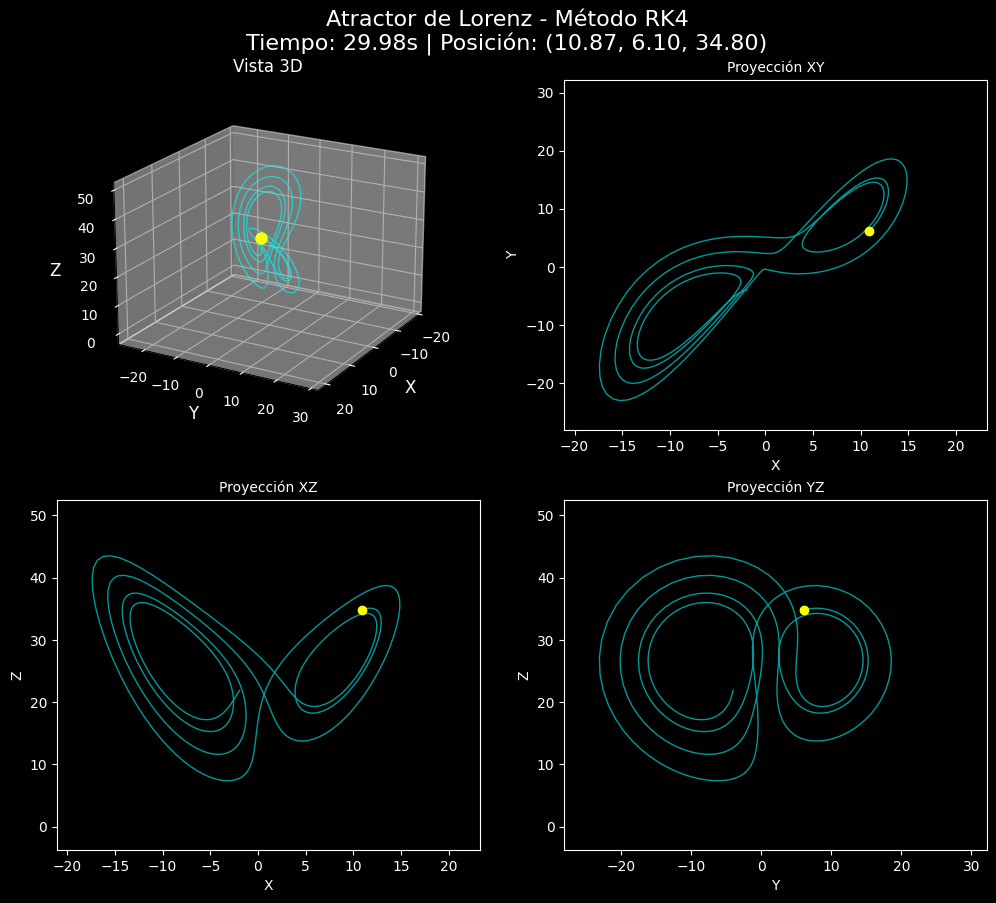

In [5]:
def generate_animation():
    animation_data = generate_animation_data()

    # PASO 1: Obtener datos
    t = animation_data['tiempo']
    x = animation_data['x_rk4']  # o x_euler
    y = animation_data['y_rk4']
    z = animation_data['z_rk4']
    
    # PASO 2: Crear el animador
    animator = LorenzAnimator(t, x, y, z, method_name="RK4")
    
    # PASO 3: Generar la animación, validando si el códec MP4 es válido o no
    if (verify_ffmpeg_liveness()):
        anim = animator.create_animation(
            filename="lorenz_rk4_animation.mp4",
            fps=30,
            duration=50,
            dpi=150
        )
    else:
        anim = animator.create_animation(
            filename="lorenz_rk4_animation.gif",
            fps=25,
            duration=30,
            dpi=100
        )

if __name__ == "__main__":
    generate_animation()

## Bibliografía

[1] E. N. Lorenz, "Deterministic nonperiodic flow", 1963.

[2] S. H. Strogatz, Nonlinear Dynamics and Chaos: With Applications to Physics, Biology, Chemistry, and Engineering. Reading, MA, USA: Perseus Books, 1994.

[3] J. Stewart, *Calculus: Early Transcendentals*, 8th ed. Boston, MA, USA: Cengage Learning.

[4] K. T. Alligood, T. D. Sauer, and J. A. Yorke, *Chaos: An Introduction to Dynamical Systems*. New York, NY, USA: Springer, 1996.

In [ ]:
[5] R. L. Burden y J. D. Faires, Numerical Analysis, 9th ed., Brooks/Cole, Cengage Learning, 2011, cap. 5.